In [12]:
import os

repo_root = r"C:\Users\BIT\CODESPRINT_AMEX"

os.chdir(repo_root)
print(f"Working directory: {os.getcwd()}")
print(f"Contents of data/: {os.listdir('data/')}")

Working directory: C:\Users\BIT\CODESPRINT_AMEX
Contents of data/: ['.gitkeep', 'features.csv', 'target.csv']



Loading data...
Features: (50000, 26)
Target: (50000, 2)
Merged: (50000, 27)

X shape: (50000, 25)
y distribution:
target
0    0.6146
1    0.3854
Name: proportion, dtype: float64

Split sizes:
  Train: (40005, 25)
  Val: (4995, 25)
  Test: (5000, 25)

✓ Scaler saved

Training XGBoost model...
[0]	validation_0-logloss:0.65706
[20]	validation_0-logloss:0.57561
[40]	validation_0-logloss:0.55888


C:\Users\BIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\callback.py:385: UserWarning: [21:39:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[60]	validation_0-logloss:0.55582
[80]	validation_0-logloss:0.55509
[100]	validation_0-logloss:0.55498
[120]	validation_0-logloss:0.55501
[140]	validation_0-logloss:0.55518
[143]	validation_0-logloss:0.55530

✓ Model trained!

MODEL EVALUATION

✓ Test AUC-ROC: 0.7715

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79      3073
           1       0.68      0.50      0.58      1927

    accuracy                           0.72      5000
   macro avg       0.71      0.68      0.68      5000
weighted avg       0.71      0.72      0.71      5000


✓ Top 10 Most Important Features:
   1. card_type_platinum        : 0.5847
   2. card_type_gold            : 0.1402
   3. days_as_customer          : 0.0397
   4. frequency                 : 0.0361
   5. recency_days              : 0.0330
   6. monthly_spend_7           : 0.0275
   7. category_diversity        : 0.0208
   8. income_proxy              : 0.0199
   9. monetary    

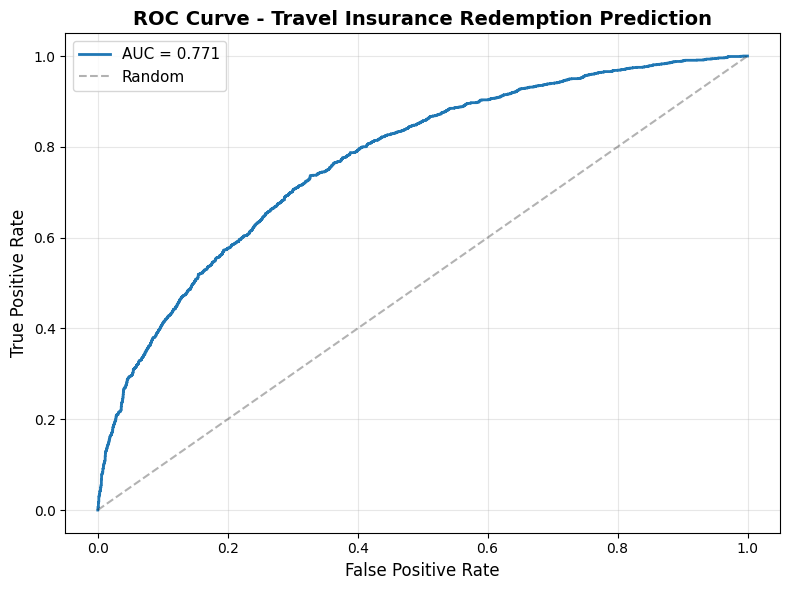


✓ MODEL READY FOR DEPLOYMENT


In [13]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import pickle
import matplotlib.pyplot as plt



# =====================================================
# LOAD DATA
# =====================================================

print("\nLoading data...")

features = pd.read_csv('data/features.csv')
target = pd.read_csv('data/target.csv')

print(f"Features: {features.shape}")
print(f"Target: {target.shape}")

# Merge
data = features.merge(target, on='user_id')
print(f"Merged: {data.shape}")

# Prepare X and y
X = data.drop(['user_id', 'target'], axis=1)
y = data['target']

print(f"\nX shape: {X.shape}")
print(f"y distribution:\n{y.value_counts(normalize=True)}")

# =====================================================
# TRAIN/VAL/TEST SPLIT (80/10/10)
# =====================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape}")
print(f"  Val: {X_val.shape}")
print(f"  Test: {X_test.shape}")

# =====================================================
# STANDARDIZE FEATURES
# =====================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler
os.makedirs('models', exist_ok=True)
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
print("\n✓ Scaler saved")

# =====================================================
# TRAIN XGBOOST
# =====================================================

print("\nTraining XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=20,
)

# Train with early stopping
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=20
)

print(f"\n✓ Model trained!")

# =====================================================
# EVALUATE
# =====================================================

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Predictions
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\n✓ Test AUC-ROC: {auc_score:.4f}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns

print(f"\n✓ Top 10 Most Important Features:")
top_indices = np.argsort(importances)[-10:][::-1]
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:25s} : {importances[idx]:.4f}")

# =====================================================
# SAVE MODEL
# =====================================================

pickle.dump(model, open('models/benefit_model.pkl', 'wb'))
print(f"\n✓ Model saved to models/benefit_model.pkl")

# =====================================================
# PLOT ROC CURVE
# =====================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.3)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Travel Insurance Redemption Prediction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

os.makedirs('reports', exist_ok=True)
plt.savefig('reports/roc_curve.png', dpi=100)
print(f"\n✓ ROC curve saved to reports/roc_curve.png")
plt.show()

print(f"\n{'='*50}")
print("✓ MODEL READY FOR DEPLOYMENT")
print(f"{'='*50}")

In [14]:
import pandas as pd

t = pd.read_csv('data/target.csv')
print(t['target'].value_counts(normalize=True))

target
0    0.6146
1    0.3854
Name: proportion, dtype: float64
